# CNN Baselines — ResNet-50 & EfficientNet-B0

**Purpose:** Train ResNet-50 and EfficientNet-B0 as CNN baselines to compare against YOLO26, ViT-B/16, and DINOv2.

**Your folder structure (same as before):**
```
code/
├── cnn_baselines.ipynb       ← this notebook
├── deepweeds_data/           ← your existing DeepWeeds splits
│   ├── train/
│   │   ├── Chinee apple/
│   │   ├── Lantana/
│   │   └── ... (all 9 classes)
│   └── val/
│       ├── Chinee apple/
│       └── ...
└── my_images/                ← your 350 Albanian photos
```

**What this notebook produces:**
- `best_resnet50.pth` — trained ResNet-50 weights
- `best_efficientnet.pth` — trained EfficientNet-B0 weights
- Validation accuracy, F1, confusion matrix for both models
- Inference latency measurements
- Cross-domain inference on your 350 Albanian images
- All figures ready to paste into your paper

In [1]:
# ============================================================
# CELL 1 — INSTALL & IMPORTS
# ============================================================
!pip install torch torchvision pillow matplotlib scikit-learn timm -q

import os, glob, time, warnings, csv
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms, datasets, models
from PIL import Image
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)
from collections import Counter

warnings.filterwarnings('ignore')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

CLASS_NAMES = [
    'Chinee apple', 'Lantana', 'Parkinsonia', 'Parthenium',
    'Prickly acacia', 'Rubber vine', 'Siam weed', 'Snake weed', 'Negative'
]
NUM_CLASSES = 9

# Paths — same as your existing notebook
TRAIN_DIR = './deepweeds_data/train'
VAL_DIR   = './deepweeds_data/val'
MY_IMAGES = './my_images'

print('✅ Imports done!')

Using device: cpu
✅ Imports done!


In [16]:
# ============================================================
# CELL 2 — DATA LOADERS
# ============================================================
import os

# These are set directly — no auto-detection needed
TRAIN_DIR = './deepweeds_data/train'
VAL_DIR   = './deepweeds_data/val'

# Check they exist
if not os.path.isdir(TRAIN_DIR):
    print('❌ TRAIN_DIR not found:', TRAIN_DIR)
    print('   Run Cell 2B first, then re-run this cell')
else:
    print(f'✅ TRAIN_DIR found: {TRAIN_DIR}')
    print(f'   Classes: {sorted(os.listdir(TRAIN_DIR))}')

if not os.path.isdir(VAL_DIR):
    print('❌ VAL_DIR not found:', VAL_DIR)
else:
    print(f'✅ VAL_DIR found: {VAL_DIR}')

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(45),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
val_dataset   = datasets.ImageFolder(VAL_DIR,   transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False,
                          num_workers=2, pin_memory=True)

folder_to_class = train_dataset.class_to_idx
idx_to_class    = {v: k for k, v in folder_to_class.items()}

print(f'\nTrain samples : {len(train_dataset)}')
print(f'Val samples   : {len(val_dataset)}')
print(f'Class mapping : {folder_to_class}')
print('✅ Data loaders ready!')

✅ TRAIN_DIR found: ./deepweeds_data/train
   Classes: ['Chinee apple', 'Lantana', 'Negative', 'Parkinsonia', 'Parthenium', 'Prickly acacia', 'Rubber vine', 'Siam weed', 'Snake weed']
✅ VAL_DIR found: ./deepweeds_data/val

Train samples : 1393
Val samples   : 354
Class mapping : {'Chinee apple': 0, 'Lantana': 1, 'Negative': 2, 'Parkinsonia': 3, 'Parthenium': 4, 'Prickly acacia': 5, 'Rubber vine': 6, 'Siam weed': 7, 'Snake weed': 8}
✅ Data loaders ready!


In [17]:
# # ============================================================
# # CELL 2B — CREATE TRAIN/VAL SPLIT FROM deepweeds_data/images/
# # ============================================================
# import shutil, random
# from sklearn.model_selection import train_test_split

# SOURCE_DIR = './deepweeds_data/images'   # where your 9 class folders are
# TRAIN_DIR  = './deepweeds_data/train'
# VAL_DIR    = './deepweeds_data/val'

# RANDOM_SEED  = 42     # same seed as your paper
# VAL_FRACTION = 0.20   # 80/20 split

# print(f'Source: {SOURCE_DIR}')
# print(f'Classes found: {os.listdir(SOURCE_DIR)}')
# print()

# for cls in sorted(os.listdir(SOURCE_DIR)):
#     cls_path = os.path.join(SOURCE_DIR, cls)
#     if not os.path.isdir(cls_path):
#         continue

#     images = [f for f in os.listdir(cls_path)
#               if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

#     if len(images) == 0:
#         print(f'  ⚠️  {cls}: no images found, skipping')
#         continue

#     train_imgs, val_imgs = train_test_split(
#         images,
#         test_size=VAL_FRACTION,
#         random_state=RANDOM_SEED
#     )

#     for split_name, split_imgs in [('train', train_imgs), ('val', val_imgs)]:
#         dest = os.path.join('./deepweeds_data', split_name, cls)
#         os.makedirs(dest, exist_ok=True)
#         for img in split_imgs:
#             shutil.copy2(
#                 os.path.join(cls_path, img),
#                 os.path.join(dest, img)
#             )

#     print(f'  {cls:<18}: {len(train_imgs):4d} train  {len(val_imgs):4d} val')

# TRAIN_DIR = './deepweeds_data/train'
# VAL_DIR   = './deepweeds_data/val'

# print(f'\n✅ Split complete!')
# print(f'   TRAIN_DIR = {TRAIN_DIR}')
# print(f'   VAL_DIR   = {VAL_DIR}')

In [14]:
# ============================================================
# FIX — CREATE TRAIN/VAL SPLIT FROM labels.csv
# ============================================================
import os, shutil, csv
from collections import defaultdict
from sklearn.model_selection import train_test_split

IMAGES_DIR = './deepweeds_data/images'
LABELS_CSV = './deepweeds_data/labels.csv'
TRAIN_DIR  = './deepweeds_data/train'
VAL_DIR    = './deepweeds_data/val'

# Step 1: Read CSV and group filenames by species
species_to_files = defaultdict(list)

with open(LABELS_CSV, 'r') as f:
    reader = csv.DictReader(f)
    for row in reader:
        species_to_files[row['Species']].append(row['Filename'])

print('Class counts in full dataset:')
for cls, files in sorted(species_to_files.items()):
    print(f'  {cls:<20}: {len(files)} images')
print(f'  Total: {sum(len(v) for v in species_to_files.values())}')
print()

# Step 2: Stratified 10% sample (same as your paper — seed 42)
# Then split that 10% into 80% train / 20% val
print('Creating stratified 10% sample then 80/20 train/val split...')
print()

total_train = 0
total_val   = 0

for cls, all_files in sorted(species_to_files.items()):
    # 10% stratified sample
    sample_size = max(1, int(len(all_files) * 0.10))
    import random
    random.seed(42)
    sampled = random.sample(all_files, sample_size)

    # 80/20 train/val split
    train_imgs, val_imgs = train_test_split(
        sampled, test_size=0.20, random_state=42
    )

    # Copy files
    for split_name, split_imgs in [('train', train_imgs), ('val', val_imgs)]:
        dest = os.path.join(
            TRAIN_DIR if split_name == 'train' else VAL_DIR, cls
        )
        os.makedirs(dest, exist_ok=True)
        for img in split_imgs:
            src = os.path.join(IMAGES_DIR, img)
            dst = os.path.join(dest, img)
            if os.path.exists(src):
                shutil.copy2(src, dst)

    total_train += len(train_imgs)
    total_val   += len(val_imgs)
    print(f'  {cls:<20}: {len(train_imgs):4d} train  {len(val_imgs):4d} val')

print(f'\n  Total: {total_train} train  {total_val} val')
print(f'\n✅ Done!')
print(f'   TRAIN_DIR = {TRAIN_DIR}')
print(f'   VAL_DIR   = {VAL_DIR}')
print()
print('Now re-run Cell 2 (the data loaders cell) and continue!')

Class counts in full dataset:
  Chinee apple        : 1125 images
  Lantana             : 1064 images
  Negative            : 9106 images
  Parkinsonia         : 1031 images
  Parthenium          : 1022 images
  Prickly acacia      : 1062 images
  Rubber vine         : 1009 images
  Siam weed           : 1074 images
  Snake weed          : 1016 images
  Total: 17509

Creating stratified 10% sample then 80/20 train/val split...

  Chinee apple        :   89 train    23 val
  Lantana             :   84 train    22 val
  Negative            :  728 train   182 val
  Parkinsonia         :   82 train    21 val
  Parthenium          :   81 train    21 val
  Prickly acacia      :   84 train    22 val
  Rubber vine         :   80 train    20 val
  Siam weed           :   85 train    22 val
  Snake weed          :   80 train    21 val

  Total: 1393 train  354 val

✅ Done!
   TRAIN_DIR = ./deepweeds_data/train
   VAL_DIR   = ./deepweeds_data/val

Now re-run Cell 2 (the data loaders cell) and con

In [18]:
# ============================================================
# CELL 3 — TRAINING FUNCTION
# Reused for both ResNet-50 and EfficientNet-B0
# ============================================================

def train_model(model, model_name, save_path, num_epochs=15, patience=3):
    """
    Full fine-tune with AdamW + cross-entropy + early stopping.
    Same protocol as your ViT training.
    """
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

    best_val_loss = float('inf')
    patience_counter = 0
    best_epoch = 0

    train_losses, val_losses, val_accs = [], [], []

    print(f'\n========== Training {model_name} ==========')

    for epoch in range(1, num_epochs + 1):
        # --- TRAIN ---
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)

        train_loss = running_loss / len(train_dataset)
        train_losses.append(train_loss)

        # --- VALIDATE ---
        model.eval()
        val_loss = 0.0
        correct = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)
                preds = outputs.argmax(dim=1)
                correct += (preds == labels).sum().item()

        val_loss /= len(val_dataset)
        val_acc   = correct / len(val_dataset)
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        scheduler.step()

        print(f'Epoch {epoch:2d}/{num_epochs} | '
              f'Train Loss: {train_loss:.4f} | '
              f'Val Loss: {val_loss:.4f} | '
              f'Val Acc: {val_acc*100:.2f}%')

        # --- EARLY STOPPING ---
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch    = epoch
            patience_counter = 0
            torch.save(model.state_dict(), save_path)
            print(f'   ✅ Best model saved (epoch {epoch})')
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f'   ⏹  Early stopping at epoch {epoch} '
                      f'(best was epoch {best_epoch})')
                break

    print(f'\n✅ {model_name} training done. Best epoch: {best_epoch}')
    return train_losses, val_losses, val_accs, best_epoch

In [19]:
# ============================================================
# CELL 4 — BUILD & TRAIN RESNET-50
# ImageNet pretrained, replace final FC layer for 9 classes
# ============================================================

resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
resnet.fc = nn.Linear(resnet.fc.in_features, NUM_CLASSES)

print(f'ResNet-50 parameters: {sum(p.numel() for p in resnet.parameters())/1e6:.1f}M')

resnet_train_losses, resnet_val_losses, resnet_val_accs, resnet_best_epoch = train_model(
    resnet,
    model_name='ResNet-50',
    save_path='./best_resnet50.pth',
    num_epochs=15,
    patience=3
)

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to C:\Users\rkumar/.cache\torch\hub\checkpoints\resnet50-0676ba61.pth


100%|█████████████████████████████████████████████████████████████████████████████| 97.8M/97.8M [00:03<00:00, 30.0MB/s]


ResNet-50 parameters: 23.5M

========== Training ResNet-50 ==========
Epoch  1/15 | Train Loss: 1.6913 | Val Loss: 1.4216 | Val Acc: 58.19%
   ✅ Best model saved (epoch 1)
Epoch  2/15 | Train Loss: 1.1587 | Val Loss: 1.0406 | Val Acc: 66.38%
   ✅ Best model saved (epoch 2)
Epoch  3/15 | Train Loss: 0.9200 | Val Loss: 0.8082 | Val Acc: 73.73%
   ✅ Best model saved (epoch 3)
Epoch  4/15 | Train Loss: 0.7702 | Val Loss: 0.6834 | Val Acc: 79.10%
   ✅ Best model saved (epoch 4)
Epoch  5/15 | Train Loss: 0.6351 | Val Loss: 0.6094 | Val Acc: 81.64%
   ✅ Best model saved (epoch 5)
Epoch  6/15 | Train Loss: 0.5517 | Val Loss: 0.5402 | Val Acc: 82.77%
   ✅ Best model saved (epoch 6)
Epoch  7/15 | Train Loss: 0.4705 | Val Loss: 0.5315 | Val Acc: 81.92%
   ✅ Best model saved (epoch 7)
Epoch  8/15 | Train Loss: 0.4438 | Val Loss: 0.5169 | Val Acc: 83.33%
   ✅ Best model saved (epoch 8)
Epoch  9/15 | Train Loss: 0.4075 | Val Loss: 0.5362 | Val Acc: 81.92%
Epoch 10/15 | Train Loss: 0.3605 | Val Loss:

In [20]:
# ============================================================
# CELL 5 — BUILD & TRAIN EFFICIENTNET-B0
# ImageNet pretrained, replace classifier for 9 classes
# ============================================================

effnet = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
effnet.classifier[1] = nn.Linear(effnet.classifier[1].in_features, NUM_CLASSES)

print(f'EfficientNet-B0 parameters: {sum(p.numel() for p in effnet.parameters())/1e6:.1f}M')

effnet_train_losses, effnet_val_losses, effnet_val_accs, effnet_best_epoch = train_model(
    effnet,
    model_name='EfficientNet-B0',
    save_path='./best_efficientnet.pth',
    num_epochs=15,
    patience=3
)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\rkumar/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth


100%|█████████████████████████████████████████████████████████████████████████████| 20.5M/20.5M [00:00<00:00, 29.8MB/s]


EfficientNet-B0 parameters: 4.0M

========== Training EfficientNet-B0 ==========
Epoch  1/15 | Train Loss: 2.0959 | Val Loss: 2.0482 | Val Acc: 31.92%
   ✅ Best model saved (epoch 1)
Epoch  2/15 | Train Loss: 1.9460 | Val Loss: 1.9552 | Val Acc: 42.37%
   ✅ Best model saved (epoch 2)
Epoch  3/15 | Train Loss: 1.7971 | Val Loss: 1.8523 | Val Acc: 50.00%
   ✅ Best model saved (epoch 3)
Epoch  4/15 | Train Loss: 1.6556 | Val Loss: 1.7912 | Val Acc: 52.26%
   ✅ Best model saved (epoch 4)
Epoch  5/15 | Train Loss: 1.5519 | Val Loss: 1.6901 | Val Acc: 56.78%
   ✅ Best model saved (epoch 5)
Epoch  6/15 | Train Loss: 1.4397 | Val Loss: 1.6332 | Val Acc: 59.32%
   ✅ Best model saved (epoch 6)
Epoch  7/15 | Train Loss: 1.3801 | Val Loss: 1.6204 | Val Acc: 58.76%
   ✅ Best model saved (epoch 7)
Epoch  8/15 | Train Loss: 1.3240 | Val Loss: 1.5715 | Val Acc: 58.19%
   ✅ Best model saved (epoch 8)
Epoch  9/15 | Train Loss: 1.2855 | Val Loss: 1.5013 | Val Acc: 61.30%
   ✅ Best model saved (epoch 9)
E

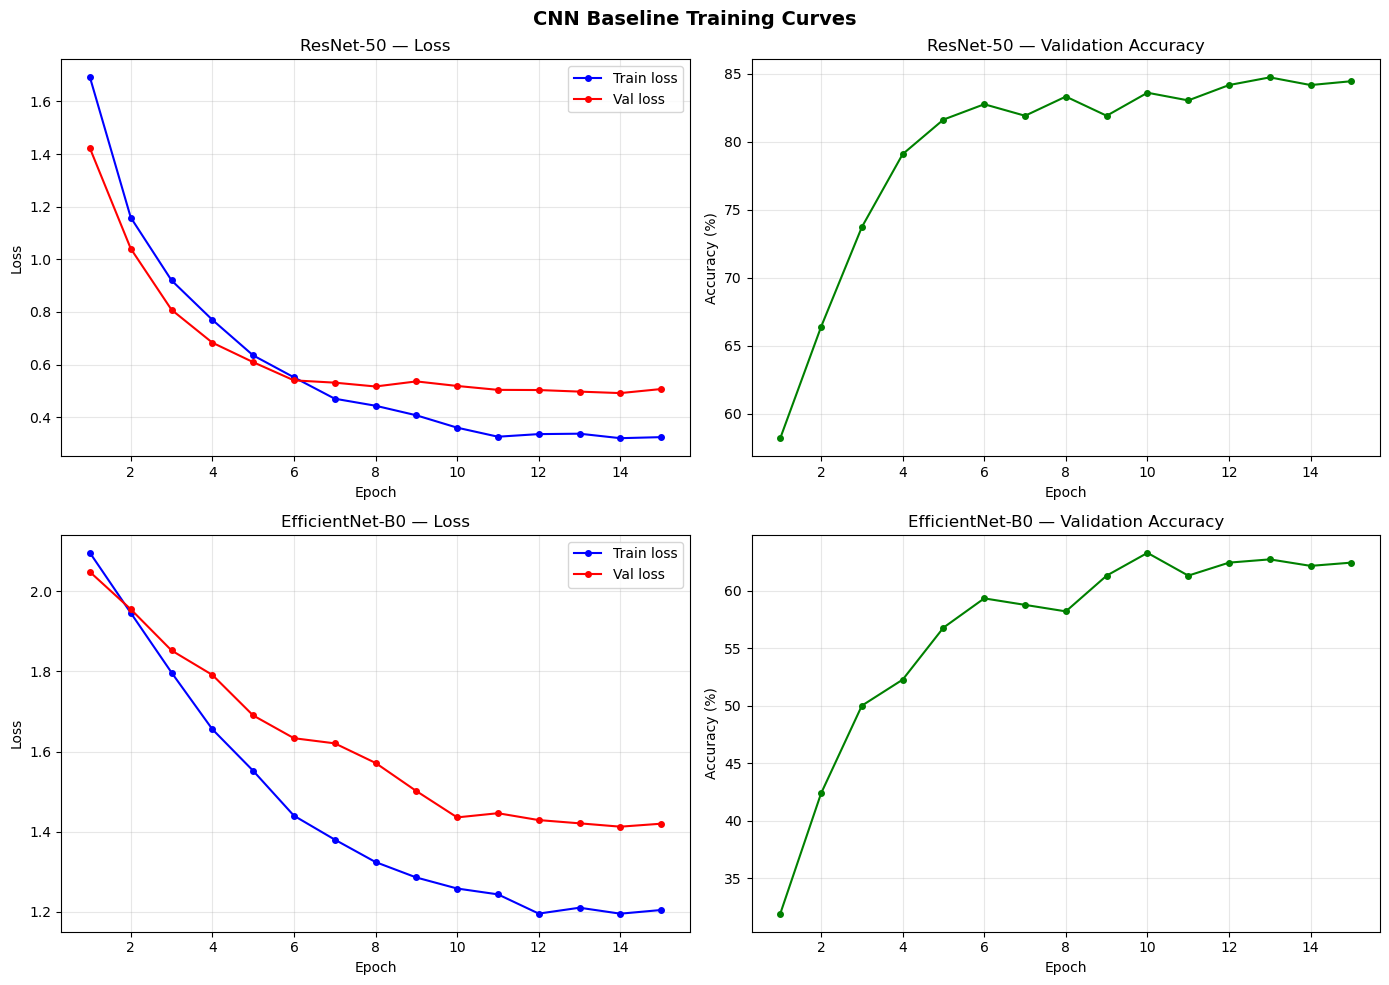

✅ Saved: cnn_training_curves.png


In [21]:
# ============================================================
# CELL 6 — PLOT TRAINING CURVES (both models side by side)
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for row, (name, t_loss, v_loss, v_acc) in enumerate([
    ('ResNet-50',       resnet_train_losses, resnet_val_losses, resnet_val_accs),
    ('EfficientNet-B0', effnet_train_losses, effnet_val_losses, effnet_val_accs),
]):
    epochs = range(1, len(t_loss) + 1)

    axes[row, 0].plot(epochs, t_loss, 'b-o', markersize=4, label='Train loss')
    axes[row, 0].plot(epochs, v_loss, 'r-o', markersize=4, label='Val loss')
    axes[row, 0].set_title(f'{name} — Loss')
    axes[row, 0].set_xlabel('Epoch')
    axes[row, 0].set_ylabel('Loss')
    axes[row, 0].legend()
    axes[row, 0].grid(True, alpha=0.3)

    axes[row, 1].plot(epochs, [a*100 for a in v_acc], 'g-o', markersize=4)
    axes[row, 1].set_title(f'{name} — Validation Accuracy')
    axes[row, 1].set_xlabel('Epoch')
    axes[row, 1].set_ylabel('Accuracy (%)')
    axes[row, 1].grid(True, alpha=0.3)

plt.suptitle('CNN Baseline Training Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('./cnn_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: cnn_training_curves.png')

In [24]:
# ============================================================
# CELL 7 — EVALUATION FUNCTION
# Full classification report + confusion matrix
# ============================================================

def evaluate_model(model, weights_path, model_name):
    """
    Load best weights and run full evaluation on val set.
    Returns: accuracy, per-class report, confusion matrix
    """
    model.load_state_dict(torch.load(weights_path, map_location=device))
    model = model.to(device)
    model.eval()

    all_preds  = []
    all_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            outputs = model(images)
            preds = outputs.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    # Map indices to class names using folder mapping
    pred_names  = [idx_to_class[p] for p in all_preds]
    label_names = [idx_to_class[l] for l in all_labels]

    acc = accuracy_score(label_names, pred_names)
    report = classification_report(
        label_names, pred_names,
        target_names=CLASS_NAMES,
        digits=2,
        output_dict=True
    )
    cm = confusion_matrix(label_names, pred_names, labels=CLASS_NAMES)

    print(f'\n========== {model_name} Validation Results ==========')
    print(f'Top-1 Accuracy: {acc*100:.2f}%')
    print()
    print(classification_report(
        label_names, pred_names,
        target_names=CLASS_NAMES,
        digits=2
    ))

    return acc, report, cm, pred_names, label_names

In [39]:
# ============================================================
# CELL 8 — EVALUATE RESNET-50
# ============================================================

resnet_eval = models.resnet50()
resnet_eval.fc = nn.Linear(resnet_eval.fc.in_features, NUM_CLASSES)

resnet_acc, resnet_report, resnet_cm, resnet_preds, resnet_labels = evaluate_model(
    resnet_eval, './best_resnet50.pth', 'ResNet-50'
)


========== ResNet-50 Validation Results ==========
Top-1 Accuracy: 84.18%

                precision    recall  f1-score   support

  Chinee apple       0.92      0.48      0.63        23
       Lantana       0.72      0.82      0.77        22
   Parkinsonia       0.85      0.97      0.90       182
    Parthenium       0.88      1.00      0.93        21
Prickly acacia       0.92      0.52      0.67        21
   Rubber vine       0.95      0.86      0.90        22
     Siam weed       0.88      0.70      0.78        20
    Snake weed       0.88      0.68      0.77        22
      Negative       0.65      0.62      0.63        21

      accuracy                           0.84       354
     macro avg       0.85      0.74      0.78       354
  weighted avg       0.85      0.84      0.83       354



In [40]:
# ============================================================
# CELL 9 — EVALUATE EFFICIENTNET-B0
# ============================================================

effnet_eval = models.efficientnet_b0()
effnet_eval.classifier[1] = nn.Linear(effnet_eval.classifier[1].in_features, NUM_CLASSES)

effnet_acc, effnet_report, effnet_cm, effnet_preds, effnet_labels = evaluate_model(
    effnet_eval, './best_efficientnet.pth', 'EfficientNet-B0'
)


========== EfficientNet-B0 Validation Results ==========
Top-1 Accuracy: 62.15%

                precision    recall  f1-score   support

  Chinee apple       0.31      0.48      0.38        23
       Lantana       0.71      0.45      0.56        22
   Parkinsonia       0.71      0.83      0.76       182
    Parthenium       0.67      0.29      0.40        21
Prickly acacia       0.50      0.10      0.16        21
   Rubber vine       0.50      0.50      0.50        22
     Siam weed       0.54      0.70      0.61        20
    Snake weed       0.48      0.64      0.55        22
      Negative       1.00      0.05      0.09        21

      accuracy                           0.62       354
     macro avg       0.60      0.45      0.45       354
  weighted avg       0.65      0.62      0.59       354



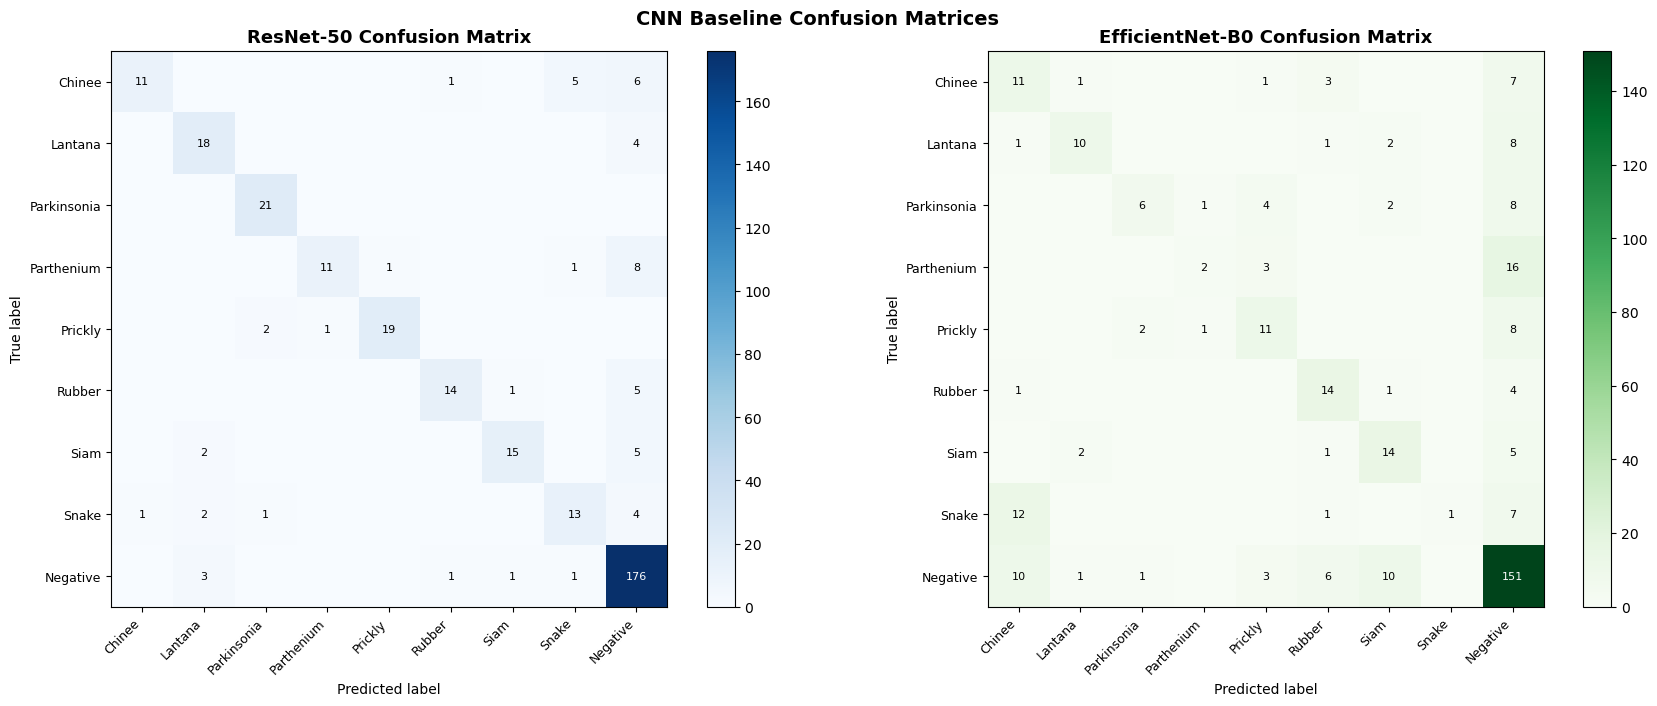

✅ Saved: cnn_confusion_matrices.png


In [41]:
# ============================================================
# CELL 10 — CONFUSION MATRICES SIDE BY SIDE
# ============================================================
import matplotlib.ticker as ticker

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, (name, cm, color) in zip(axes, [
    ('ResNet-50',       resnet_cm, 'Blues'),
    ('EfficientNet-B0', effnet_cm, 'Greens'),
]):
    im = ax.imshow(cm, interpolation='nearest', cmap=color)
    ax.set_title(f'{name} Confusion Matrix', fontsize=13, fontweight='bold')
    tick_marks = np.arange(NUM_CLASSES)
    ax.set_xticks(tick_marks)
    ax.set_yticks(tick_marks)
    short = [c.split()[0] for c in CLASS_NAMES]  # shorter labels
    ax.set_xticklabels(short, rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(short, fontsize=9)
    ax.set_ylabel('True label')
    ax.set_xlabel('Predicted label')

    thresh = cm.max() / 2.0
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            if cm[i, j] > 0:
                ax.text(j, i, str(cm[i, j]),
                        ha='center', va='center', fontsize=8,
                        color='white' if cm[i, j] > thresh else 'black')
    plt.colorbar(im, ax=ax)

plt.suptitle('CNN Baseline Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('./cnn_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: cnn_confusion_matrices.png')

In [42]:
# ============================================================
# CELL 11 — INFERENCE LATENCY MEASUREMENT
# Measures forward-pass time per image on your hardware
# ============================================================

def measure_latency(model, weights_path, model_name, n_warmup=10, n_runs=100):
    """
    Measures average forward-pass latency per single image.
    Uses same protocol: warmup runs then timed runs.
    """
    model.load_state_dict(torch.load(weights_path, map_location=device))
    model = model.to(device)
    model.eval()

    dummy = torch.randn(1, 3, 224, 224).to(device)

    # Warmup
    with torch.no_grad():
        for _ in range(n_warmup):
            _ = model(dummy)

    # Timed runs
    if device == 'cuda':
        torch.cuda.synchronize()

    times = []
    with torch.no_grad():
        for _ in range(n_runs):
            start = time.perf_counter()
            _ = model(dummy)
            if device == 'cuda':
                torch.cuda.synchronize()
            end = time.perf_counter()
            times.append((end - start) * 1000)  # ms

    mean_ms = np.mean(times)
    std_ms  = np.std(times)
    params  = sum(p.numel() for p in model.parameters()) / 1e6

    print(f'{model_name}:')
    print(f'  Parameters : {params:.1f}M')
    print(f'  Latency    : {mean_ms:.1f} ± {std_ms:.1f} ms per image')
    print(f'  Device     : {device}')
    return mean_ms, std_ms, params


print('Measuring inference latency...\n')

resnet_lat_model = models.resnet50()
resnet_lat_model.fc = nn.Linear(resnet_lat_model.fc.in_features, NUM_CLASSES)
r_mean, r_std, r_params = measure_latency(
    resnet_lat_model, './best_resnet50.pth', 'ResNet-50'
)

effnet_lat_model = models.efficientnet_b0()
effnet_lat_model.classifier[1] = nn.Linear(
    effnet_lat_model.classifier[1].in_features, NUM_CLASSES
)
e_mean, e_std, e_params = measure_latency(
    effnet_lat_model, './best_efficientnet.pth', 'EfficientNet-B0'
)

print('\n--- Summary for your paper Table 7 ---')
print(f'ResNet-50       | {r_params:.1f}M params | {r_mean:.1f} ms')
print(f'EfficientNet-B0 | {e_params:.1f}M params | {e_mean:.1f} ms')
print('(Compare: YOLO26=1.54M/0.4ms, ViT-B/16=86.6M/8-12ms, DINOv2-S/14=21.0M/3-5ms)')

Measuring inference latency...

ResNet-50:
  Parameters : 23.5M
  Latency    : 28.0 ± 2.7 ms per image
  Device     : cpu
EfficientNet-B0:
  Parameters : 4.0M
  Latency    : 12.5 ± 0.5 ms per image
  Device     : cpu

--- Summary for your paper Table 7 ---
ResNet-50       | 23.5M params | 28.0 ms
EfficientNet-B0 | 4.0M params | 12.5 ms
(Compare: YOLO26=1.54M/0.4ms, ViT-B/16=86.6M/8-12ms, DINOv2-S/14=21.0M/3-5ms)


In [43]:
# ============================================================
# CELL 12 — AGGREGATE METRICS SUMMARY TABLE
# Prints everything you need for Table 2 in your paper
# ============================================================

def extract_metrics(report):
    mac_p  = report['macro avg']['precision']
    mac_r  = report['macro avg']['recall']
    mac_f1 = report['macro avg']['f1-score']
    wt_f1  = report['weighted avg']['f1-score']
    return mac_p, mac_r, mac_f1, wt_f1

r_mac_p, r_mac_r, r_mac_f1, r_wt_f1 = extract_metrics(resnet_report)
e_mac_p, e_mac_r, e_mac_f1, e_wt_f1 = extract_metrics(effnet_report)

print('\n========== AGGREGATE METRICS FOR YOUR PAPER ==========')
print(f'{"Model":<20} {"Acc":>6} {"Mac.P":>6} {"Mac.R":>6} {"Mac.F1":>7} {"Wt.F1":>6}')
print('-' * 60)
print(f'{"ResNet-50":<20} {resnet_acc:.3f} {r_mac_p:.3f} {r_mac_r:.3f} {r_mac_f1:.3f}  {r_wt_f1:.3f}')
print(f'{"EfficientNet-B0":<20} {effnet_acc:.3f} {e_mac_p:.3f} {e_mac_r:.3f} {e_mac_f1:.3f}  {e_wt_f1:.3f}')
print()
print('--- Existing models (from your paper) ---')
print(f'{"YOLO26":<20}  0.877  0.839  0.819  0.823   0.876')
print(f'{"ViT-B/16":<20}  0.860  0.819  0.816  0.809   0.858')
print(f'{"DINOv2 (LP)":<20}  0.854  0.814  0.864  0.824   0.859')


========== AGGREGATE METRICS FOR YOUR PAPER ==========
Model                   Acc  Mac.P  Mac.R  Mac.F1  Wt.F1
------------------------------------------------------------
ResNet-50            0.842 0.848 0.739 0.776  0.833
EfficientNet-B0      0.621 0.602 0.447 0.445  0.589

--- Existing models (from your paper) ---
YOLO26                0.877  0.839  0.819  0.823   0.876
ViT-B/16              0.860  0.819  0.816  0.809   0.858
DINOv2 (LP)           0.854  0.814  0.864  0.824   0.859


In [44]:
# ============================================================
# CELL 13 — PER-CLASS COMPARISON TABLE
# Prints the rows to add to Table 6 in your paper
# ============================================================

print('\n========== PER-CLASS RESULTS FOR YOUR PAPER ==========')
print()

for model_name, report in [('ResNet-50', resnet_report), ('EfficientNet-B0', effnet_report)]:
    print(f'--- {model_name} ---')
    print(f'{"Class":<18} {"P":>5} {"R":>5} {"F1":>5} {"Supp":>5}')
    print('-' * 42)
    for cls in CLASS_NAMES:
        p  = report[cls]['precision']
        r  = report[cls]['recall']
        f1 = report[cls]['f1-score']
        s  = int(report[cls]['support'])
        print(f'{cls:<18} {p:5.2f} {r:5.2f} {f1:5.2f} {s:5d}')
    print(f'{"Macro avg":<18} '
          f'{report["macro avg"]["precision"]:5.2f} '
          f'{report["macro avg"]["recall"]:5.2f} '
          f'{report["macro avg"]["f1-score"]:5.2f}')
    print(f'{"Weighted avg":<18} '
          f'{report["weighted avg"]["precision"]:5.2f} '
          f'{report["weighted avg"]["recall"]:5.2f} '
          f'{report["weighted avg"]["f1-score"]:5.2f}')
    print()


========== PER-CLASS RESULTS FOR YOUR PAPER ==========

--- ResNet-50 ---
Class                  P     R    F1  Supp
------------------------------------------
Chinee apple        0.92  0.48  0.63    23
Lantana             0.72  0.82  0.77    22
Parkinsonia         0.85  0.97  0.90   182
Parthenium          0.88  1.00  0.93    21
Prickly acacia      0.92  0.52  0.67    21
Rubber vine         0.95  0.86  0.90    22
Siam weed           0.88  0.70  0.78    20
Snake weed          0.88  0.68  0.77    22
Negative            0.65  0.62  0.63    21
Macro avg           0.85  0.74  0.78
Weighted avg        0.85  0.84  0.83

--- EfficientNet-B0 ---
Class                  P     R    F1  Supp
------------------------------------------
Chinee apple        0.31  0.48  0.38    23
Lantana             0.71  0.45  0.56    22
Parkinsonia         0.71  0.83  0.76   182
Parthenium          0.67  0.29  0.40    21
Prickly acacia      0.50  0.10  0.16    21
Rubber vine         0.50  0.50  0.50    22
Siam weed

In [45]:
# ============================================================
# CELL 14 — CROSS-DOMAIN INFERENCE ON ALBANIAN IMAGES
# Runs ResNet-50 and EfficientNet-B0 on your 350 Albanian photos
# ============================================================

albanian_paths = sorted(set(
    glob.glob(os.path.join(MY_IMAGES, '*.jpg'))  +
    glob.glob(os.path.join(MY_IMAGES, '*.jpeg')) +
    glob.glob(os.path.join(MY_IMAGES, '*.JPG'))  +
    glob.glob(os.path.join(MY_IMAGES, '*.JPEG'))
))
print(f'Found {len(albanian_paths)} Albanian images')

inference_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

def predict_folder(model, weights_path, image_paths, model_name):
    model.load_state_dict(torch.load(weights_path, map_location=device))
    model = model.to(device)
    model.eval()
    results = []
    with torch.no_grad():
        for path in image_paths:
            img = Image.open(path).convert('RGB')
            tensor = inference_transform(img).unsqueeze(0).to(device)
            output = model(tensor)
            probs  = torch.softmax(output, dim=1)[0]
            # Map model output index to class name using folder_to_class
            pred_idx   = probs.argmax().item()
            pred_class = idx_to_class[pred_idx]
            confidence = probs[pred_idx].item()
            results.append({
                'path':       path,
                'prediction': pred_class,
                'confidence': confidence
            })
    print(f'✅ {model_name}: {len(results)} images predicted')
    return results


resnet_alb_model = models.resnet50()
resnet_alb_model.fc = nn.Linear(resnet_alb_model.fc.in_features, NUM_CLASSES)
resnet_albanian = predict_folder(
    resnet_alb_model, './best_resnet50.pth',
    albanian_paths, 'ResNet-50'
)

effnet_alb_model = models.efficientnet_b0()
effnet_alb_model.classifier[1] = nn.Linear(
    effnet_alb_model.classifier[1].in_features, NUM_CLASSES
)
effnet_albanian = predict_folder(
    effnet_alb_model, './best_efficientnet.pth',
    albanian_paths, 'EfficientNet-B0'
)

Found 350 Albanian images
✅ ResNet-50: 350 images predicted
✅ EfficientNet-B0: 350 images predicted



========== ALBANIAN IMAGE PREDICTION DISTRIBUTION ==========

Class                 ResNet-50  ResNet%    EffNet-B0  EffNet%
-----------------------------------------------------------------
Chinee apple                  3     0.9%            3     0.9%
Lantana                       9     2.6%            6     1.7%
Parkinsonia                   0     0.0%            1     0.3%
Parthenium                    1     0.3%            3     0.9%
Prickly acacia                0     0.0%            0     0.0%
Rubber vine                   0     0.0%            2     0.6%
Siam weed                   103    29.4%          116    33.1%
Snake weed                    0     0.0%            0     0.0%
Negative                    234    66.9%          219    62.6%
Total                       350   100.0%          350   100.0%

ResNet-50 vs EfficientNet-B0 agreement: 231/350 (66.0%)
Negative rate: ResNet=234/350 (66.9%) | EfficientNet=219/350 (62.6%)


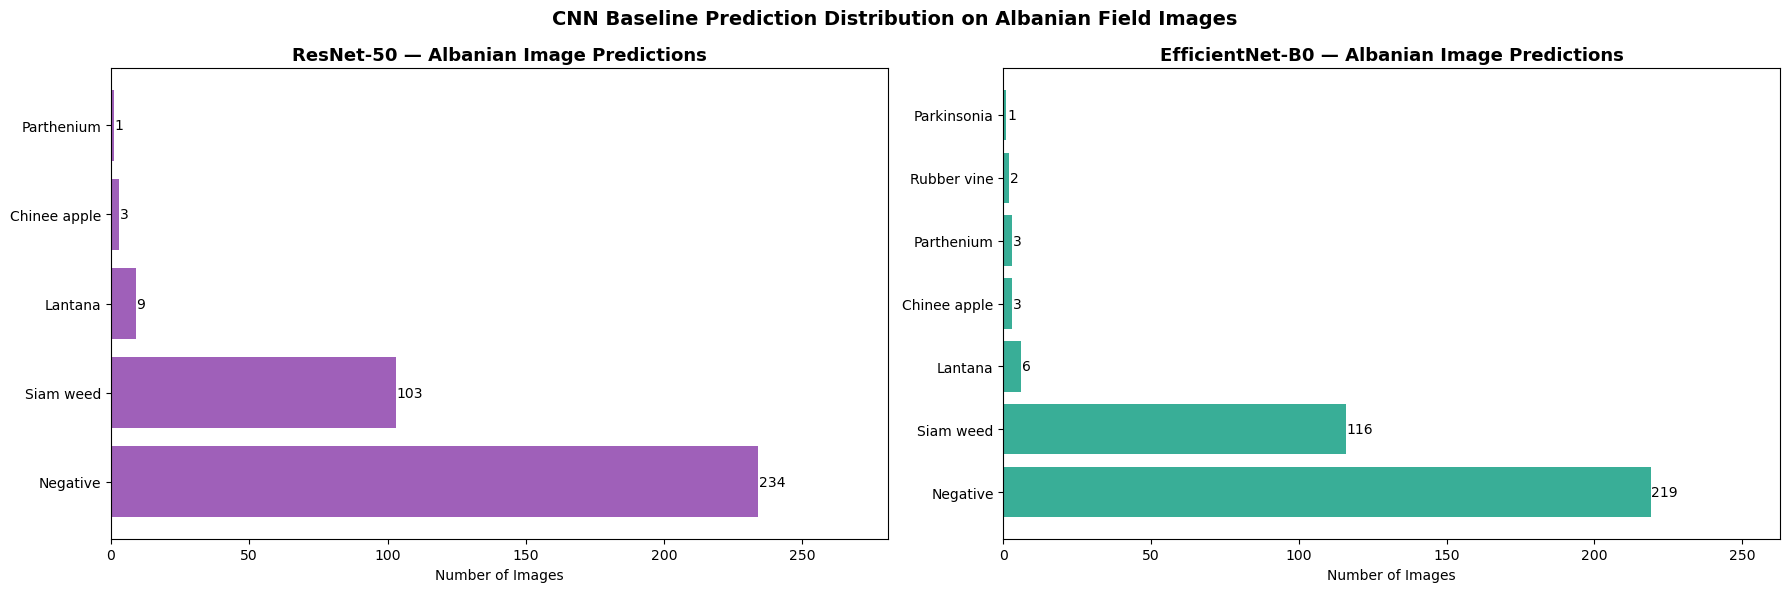

✅ Saved: cnn_albanian_bar.png


In [46]:
# ============================================================
# CELL 15 — ALBANIAN PREDICTION DISTRIBUTION
# Prints counts and percentages + bar chart
# ============================================================

resnet_alb_counts = Counter(r['prediction'] for r in resnet_albanian)
effnet_alb_counts = Counter(r['prediction'] for r in effnet_albanian)

total = len(albanian_paths)

print('\n========== ALBANIAN IMAGE PREDICTION DISTRIBUTION ==========')
print(f'\n{"Class":<18} {"ResNet-50":>12} {"ResNet%":>8} {"EffNet-B0":>12} {"EffNet%":>8}')
print('-' * 65)
for cls in CLASS_NAMES:
    r_cnt = resnet_alb_counts.get(cls, 0)
    e_cnt = effnet_alb_counts.get(cls, 0)
    print(f'{cls:<18} {r_cnt:>12} {r_cnt/total*100:>7.1f}% '
          f'{e_cnt:>12} {e_cnt/total*100:>7.1f}%')
print(f'{"Total":<18} {total:>12} {"100.0%":>8} {total:>12} {"100.0%":>8}')

# Agreement between the two models
agree = sum(
    1 for r, e in zip(resnet_albanian, effnet_albanian)
    if r['prediction'] == e['prediction']
)
print(f'\nResNet-50 vs EfficientNet-B0 agreement: {agree}/{total} ({agree/total*100:.1f}%)')
print(f'Negative rate: ResNet={resnet_alb_counts["Negative"]}/{total} '
      f'({resnet_alb_counts["Negative"]/total*100:.1f}%) | '
      f'EfficientNet={effnet_alb_counts["Negative"]}/{total} '
      f'({effnet_alb_counts["Negative"]/total*100:.1f}%)')

# Bar chart
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for ax, (name, counts, color) in zip(axes, [
    ('ResNet-50',       resnet_alb_counts, '#8e44ad'),
    ('EfficientNet-B0', effnet_alb_counts, '#16a085'),
]):
    sorted_counts = sorted(counts.items(), key=lambda x: -x[1])
    labels = [x[0] for x in sorted_counts]
    values = [x[1] for x in sorted_counts]
    bars = ax.barh(labels, values, color=color, alpha=0.85)
    ax.set_title(f'{name} — Albanian Image Predictions', fontsize=13, fontweight='bold')
    ax.set_xlabel('Number of Images')
    for bar, val in zip(bars, values):
        ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
                str(val), va='center', fontsize=10)
    ax.set_xlim(0, max(values) * 1.2 if values else 1)

plt.suptitle('CNN Baseline Prediction Distribution on Albanian Field Images',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('./cnn_albanian_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: cnn_albanian_bar.png')

In [48]:
# ============================================================
# CELL 16 — SAVE ALL RESULTS TO CSV
# One row per Albanian image with ResNet + EfficientNet predictions
# ============================================================

csv_path = './cnn_albanian_predictions.csv'

with open(csv_path, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow([
        'filename',
        'resnet50_prediction', 'resnet50_confidence_%',
        'efficientnet_prediction', 'efficientnet_confidence_%',
        'models_agree'
    ])
    for r, e in zip(resnet_albanian, effnet_albanian):
        writer.writerow([
            os.path.basename(r['path']),
            r['prediction'], round(r['confidence'] * 100, 2),
            e['prediction'], round(e['confidence'] * 100, 2),
            'YES' if r['prediction'] == e['prediction'] else 'NO'
        ])

print(f'✅ Saved: {csv_path}')
print('   Open in Excel for full per-image results!')

✅ Saved: ./cnn_albanian_predictions.csv
   Open in Excel for full per-image results!


In [49]:
# ============================================================
# CELL 17 — FINAL SUMMARY FOR YOUR PAPER
# Copy-paste ready numbers for all tables
# ============================================================

print('=' * 65)
print('  COMPLETE RESULTS SUMMARY — PASTE INTO YOUR PAPER')
print('=' * 65)

print('\n--- TABLE 2: Aggregate Validation Metrics ---')
print(f'{"Model":<20} {"Acc":>6} {"Mac.P":>6} {"Mac.R":>6} {"Mac.F1":>7} {"Wt.F1":>6}')
print('-' * 60)
print(f'{"ResNet-50":<20} {resnet_acc:.3f} {r_mac_p:.3f} {r_mac_r:.3f} {r_mac_f1:.3f}  {r_wt_f1:.3f}')
print(f'{"EfficientNet-B0":<20} {effnet_acc:.3f} {e_mac_p:.3f} {e_mac_r:.3f} {e_mac_f1:.3f}  {e_wt_f1:.3f}')
print(f'{"--- existing ---"}')
print(f'{"YOLO26":<20}  0.877  0.839  0.819  0.823   0.876')
print(f'{"ViT-B/16":<20}  0.860  0.819  0.816  0.809   0.858')
print(f'{"DINOv2 (LP)":<20}  0.854  0.814  0.864  0.824   0.859')

print('\n--- TABLE 7: Inference Latency ---')
print(f'{"Model":<20} {"Params (M)":>11} {"Latency":>10}')
print('-' * 45)
print(f'{"ResNet-50":<20} {r_params:>11.1f} {r_mean:>8.1f} ms')
print(f'{"EfficientNet-B0":<20} {e_params:>11.1f} {e_mean:>8.1f} ms')
print(f'{"--- existing ---"}')
print(f'{"YOLO26 (Nano)":<20} {"1.54":>11} {"0.4 ms":>10}')
print(f'{"ViT-B/16":<20} {"86.6":>11} {"~8-12 ms":>10}')
print(f'{"DINOv2-S/14 (LP)":<20} {"21.0":>11} {"~3-5 ms":>10}')

print('\n--- ALBANIAN DOMAIN SHIFT (for Table 8 or text) ---')
print(f'ResNet-50   Negative rate: {resnet_alb_counts["Negative"]}/{total} '
      f'({resnet_alb_counts["Negative"]/total*100:.1f}%)')
print(f'EffNet-B0   Negative rate: {effnet_alb_counts["Negative"]}/{total} '
      f'({effnet_alb_counts["Negative"]/total*100:.1f}%)')
print(f'Agreement between CNN baselines: {agree}/{total} ({agree/total*100:.1f}%)')

print('\n✅ All done! Files saved:')
print('   best_resnet50.pth')
print('   best_efficientnet.pth')
print('   cnn_training_curves.png')
print('   cnn_confusion_matrices.png')
print('   cnn_albanian_bar.png')
print('   cnn_albanian_predictions.csv')

  COMPLETE RESULTS SUMMARY — PASTE INTO YOUR PAPER

--- TABLE 2: Aggregate Validation Metrics ---
Model                   Acc  Mac.P  Mac.R  Mac.F1  Wt.F1
------------------------------------------------------------
ResNet-50            0.842 0.848 0.739 0.776  0.833
EfficientNet-B0      0.621 0.602 0.447 0.445  0.589
--- existing ---
YOLO26                0.877  0.839  0.819  0.823   0.876
ViT-B/16              0.860  0.819  0.816  0.809   0.858
DINOv2 (LP)           0.854  0.814  0.864  0.824   0.859

--- TABLE 7: Inference Latency ---
Model                 Params (M)    Latency
---------------------------------------------
ResNet-50                   23.5     28.0 ms
EfficientNet-B0              4.0     12.5 ms
--- existing ---
YOLO26 (Nano)               1.54     0.4 ms
ViT-B/16                    86.6   ~8-12 ms
DINOv2-S/14 (LP)            21.0    ~3-5 ms

--- ALBANIAN DOMAIN SHIFT (for Table 8 or text) ---
ResNet-50   Negative rate: 234/350 (66.9%)
EffNet-B0   Negative rate: 219/